In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv("/content/mymoviedb.csv", encoding='latin1', on_bad_lines='skip', engine='python')

In [63]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [64]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [65]:

# Check missing values
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [66]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [69]:
df.dropna(inplace = True)
df.isna().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


**Explore Year Trends**

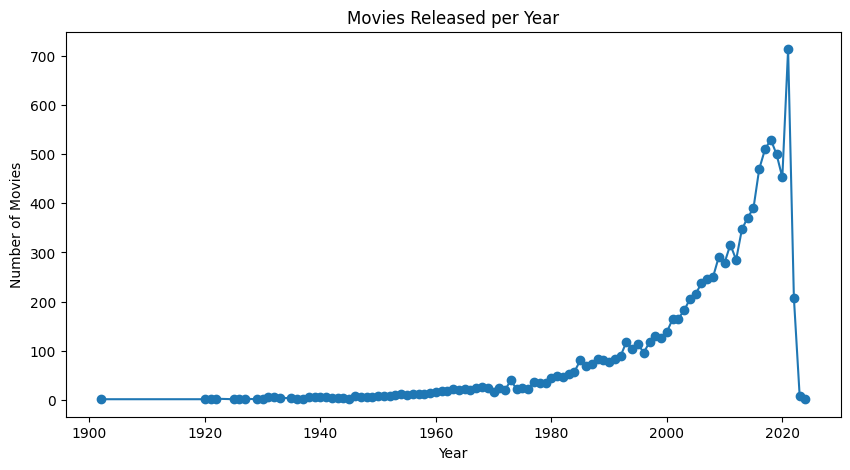

In [70]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year'] = df['Release_Date'].dt.year

year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

**Top Genres**

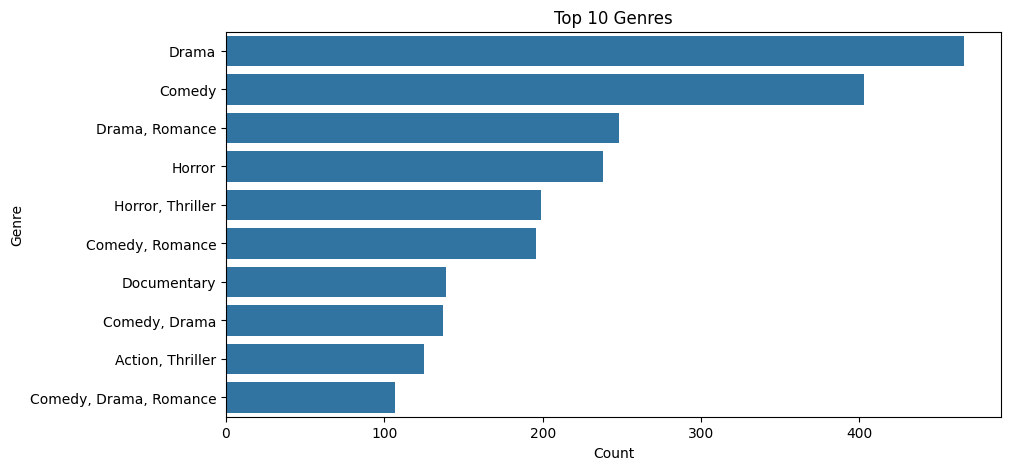

In [71]:
top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [81]:
print("Top 10 Genres")
print(df['Genre'].value_counts().head(10))

Top 10 Genres
Genre
Drama                     466
Comedy                    403
Drama, Romance            248
Horror                    238
Horror, Thriller          199
Comedy, Romance           196
Documentary               139
Comedy, Drama             137
Action, Thriller          125
Comedy, Drama, Romance    107
Name: count, dtype: int64


In [82]:
print("Top 10 Years")
print(df['Year'].value_counts().head(10))

Top 10 Years
Year
2021    714
2018    530
2017    510
2019    500
2016    470
2020    453
2015    390
2014    371
2013    347
2011    316
Name: count, dtype: int64


In [74]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021


In [77]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...,1984


**Content Growth Over Time**

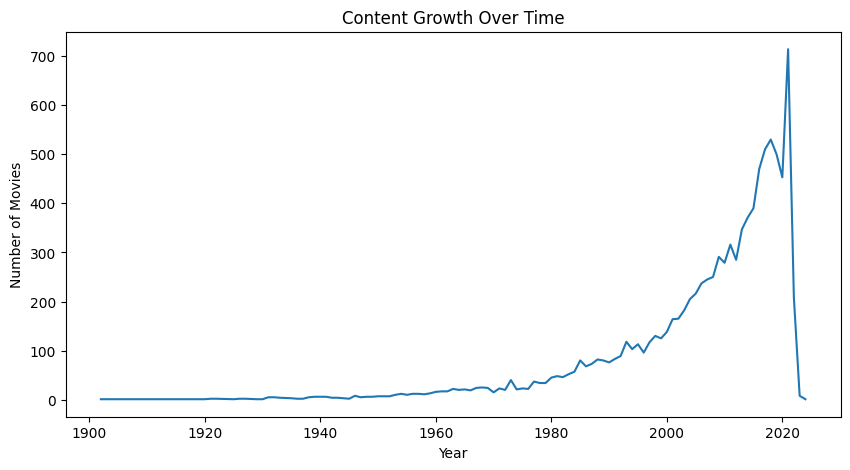

In [80]:
plt.figure(figsize=(10,5))
sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

In [83]:
print(df.columns)

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url', 'Year'],
      dtype='object')


**Vote Average Distribution**

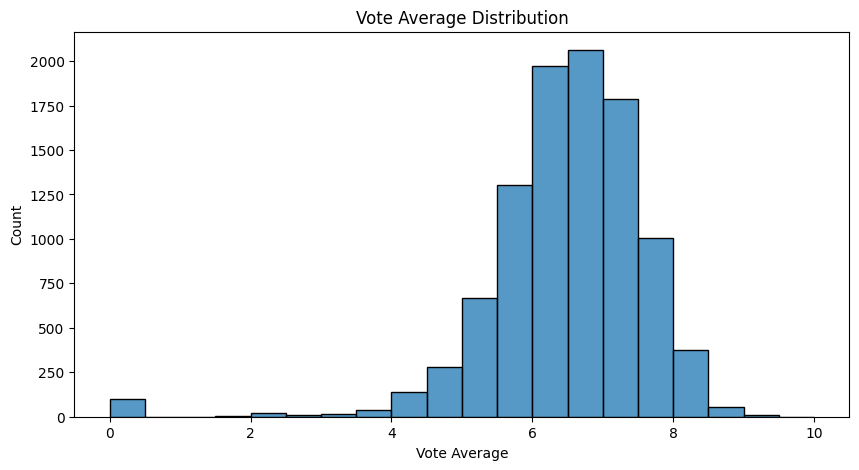

In [87]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(df['Vote_Average'], bins=20)

plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Count")

plt.show()

**Which year has the most flimmed movies?**

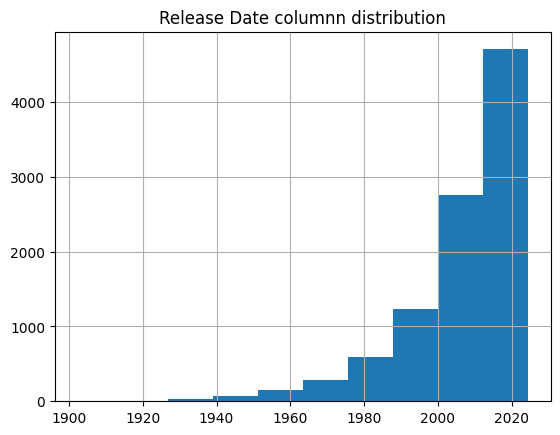

In [89]:
df['Release_Date'].hist()
plt.title('Release Date columnn distribution')
plt.show()

**Summary**


• The dataset contains movies released across multiple years, showing that movie production increased significantly in recent years.

• Drama, Action, and Comedy appear among the most common genres, indicating these are the most produced types of content.

• The vote average distribution shows that most movies have ratings between 6 and 7, meaning the majority receive moderate audience approval.

• Popularity and vote counts indicate that only a small number of movies gain very high audience engagement, while most remain moderately popular.

• The analysis helps understand content trends, genre popularity, and audience rating patterns in the movie dataset.